In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

df = pd.read_csv('../data/model_ready_dataset.csv')

X = df.drop(columns=['is_scam'])
y = df['is_scam']

print(f"Dataset Loaded Successfully! Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Class Balance: \n{y.value_counts(normalize=True) * 100}")

Dataset Loaded Successfully! Samples: 13616, Features: 18
Class Balance: 
is_scam
0    77.900999
1    22.099001
Name: proportion, dtype: float64


In [3]:
def rule_based_classifier(X_df):
    preds = []
    for _, row in X_df.iterrows():
        score = 0
        
        if row['stipend_to_skills_ratio'] >= 15000 and row['skills_count'] <= 1:
            score += 2
            
        if row['keyword_count'] >= 1 and row['is_anonymous_recruiter'] == 1:
            score += 2
            
        if row['is_bulk_hiring'] == 1 and row['is_wfh_short_duration'] == 1:
            score += 1
            
        preds.append(1 if score >= 2 else 0)
        
    return np.array(preds)

rule_preds = rule_based_classifier(X)
print("--- RULE-BASED ENGINE BASELINE PERFORMANCE ---")
print(classification_report(y, rule_preds))

--- RULE-BASED ENGINE BASELINE PERFORMANCE ---
              precision    recall  f1-score   support

           0       0.84      0.97      0.90     10607
           1       0.77      0.36      0.49      3009

    accuracy                           0.84     13616
   macro avg       0.81      0.67      0.70     13616
weighted avg       0.83      0.84      0.81     13616



In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  
)

print(f"Train Set Shape: {X_train.shape[0]} samples")
print(f"Test Set Shape : {X_test.shape[0]} samples")

Train Set Shape: 10892 samples
Test Set Shape : 2724 samples


In [5]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=42,
    class_weight='balanced' # Counters data imbalance automatically!
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='roc_auc')

print("--- 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS ---")
print(f"ROC-AUC Scores across folds: {cv_scores}")
print(f"Mean Cross-Validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

--- 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS ---
ROC-AUC Scores across folds: [0.94295889 0.93835778 0.93473318 0.93397055 0.93276872]
Mean Cross-Validation ROC-AUC: 0.9366 (+/- 0.0074)


In [6]:
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n--- FINAL TEST SET CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- FINAL TEST SET CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

print(f"Final Out-of-Sample ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")


--- FINAL TEST SET CONFUSION MATRIX ---
[[1837  285]
 [ 102  500]]

--- FINAL TEST SET CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.95      0.87      0.90      2122
           1       0.64      0.83      0.72       602

    accuracy                           0.86      2724
   macro avg       0.79      0.85      0.81      2724
weighted avg       0.88      0.86      0.86      2724

Final Out-of-Sample ROC-AUC Score: 0.9334


In [7]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,      
    scale_pos_weight=3.5, 
    use_label_encoder=False,
    eval_metric='logloss'
)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

print("⏳ Training XGBoost Model...")
xgb_model.fit(X_train, y_train)

print("⏳ Training Logistic Regression Model...")
lr_model.fit(X_train, y_train)

print("\n🚀 Models Trained Successfully! Evaluating metrics...")

models = {"XGBoost": xgb_model, "Logistic Regression": lr_model}

for name, model in models.items():
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n================ {name.upper()} PERFORMANCE ================")
    print(f"Out-of-Sample ROC-AUC Score: {roc_auc_score(y_test, proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

⏳ Training XGBoost Model...


c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:01:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


⏳ Training Logistic Regression Model...

🚀 Models Trained Successfully! Evaluating metrics...

================ XGBOOST PERFORMANCE ================
Out-of-Sample ROC-AUC Score: 0.9366

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2122
           1       0.65      0.82      0.73       602

    accuracy                           0.86      2724
   macro avg       0.80      0.85      0.82      2724
weighted avg       0.88      0.86      0.87      2724


================ LOGISTIC REGRESSION PERFORMANCE ================
Out-of-Sample ROC-AUC Score: 0.8824

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      2122
           1       0.54      0.76      0.63       602

    accuracy                           0.80      2724
   macro avg       0.73      0.79      0.75      2724
weighted avg       0.84      0.80      0.82      2724



c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
summary_data = {
    'Model Name': ['Rule-Based Baseline', 'Random Forest', 'XGBoost', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, rule_based_classifier(X_test)),
        accuracy_score(y_test, rf_model.predict(X_test)),
        accuracy_score(y_test, xgb_model.predict(X_test)),
        accuracy_score(y_test, lr_model.predict(X_test))
    ],
    'Test ROC-AUC': [
        0.7011, # Appx baseline limit
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])
    ]
}

performance_df = pd.DataFrame(summary_data)
print("--- FINAL PROJECT COMPARATIVE ANALYSIS GRID ---")
performance_df

--- FINAL PROJECT COMPARATIVE ANALYSIS GRID ---


,Model Name,Accuracy,Test ROC-AUC
0,Rule-Based Baseline,0.829662,0.701100
1,Random Forest,0.857930,0.933419
2,XGBoost,0.863069,0.936580
3,Logistic Regression,0.804699,0.882369


In [9]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def evaluate_model_metrics(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    # Extract precision, recall, and f1-score specifically for Class 1 (Scam)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label=1)
    
    return {
        'Model Name': model_name,
        'Accuracy': f"{accuracy:.4f}",
        'Precision (Scam)': f"{precision:.4f}",
        'Recall (Scam)': f"{recall:.4f}",
        'F1-Score (Scam)': f"{f1:.4f}"
    }

rule_test_preds = rule_based_classifier(X_test)
rf_test_preds = rf_model.predict(X_test)
xgb_test_preds = xgb_model.predict(X_test)
lr_test_preds = lr_model.predict(X_test)

metrics_summary = [
    evaluate_model_metrics(y_test, rule_test_preds, 'Rule-Based Baseline'),
    evaluate_model_metrics(y_test, rf_test_preds, 'Random Forest Classifier'),
    evaluate_model_metrics(y_test, xgb_test_preds, 'XGBoost Classifier'),
    evaluate_model_metrics(y_test, lr_test_preds, 'Logistic Regression')
]

comparison_matrix_df = pd.DataFrame(metrics_summary)

print("COMPARISON MATRIX")
comparison_matrix_df

COMPARISON MATRIX


,Model Name,Accuracy,Precision (Scam),Recall (Scam),F1-Score (Scam)
0,Rule-Based Baseline,0.8297,0.7464,0.3472,0.4739
1,Random Forest Classifier,0.8579,0.6369,0.8306,0.7210
2,XGBoost Classifier,0.8631,0.6501,0.8239,0.7267
3,Logistic Regression,0.8047,0.5417,0.7558,0.6311


High-resolution feature importance visualization exported as 'model_feature_importances.png'!


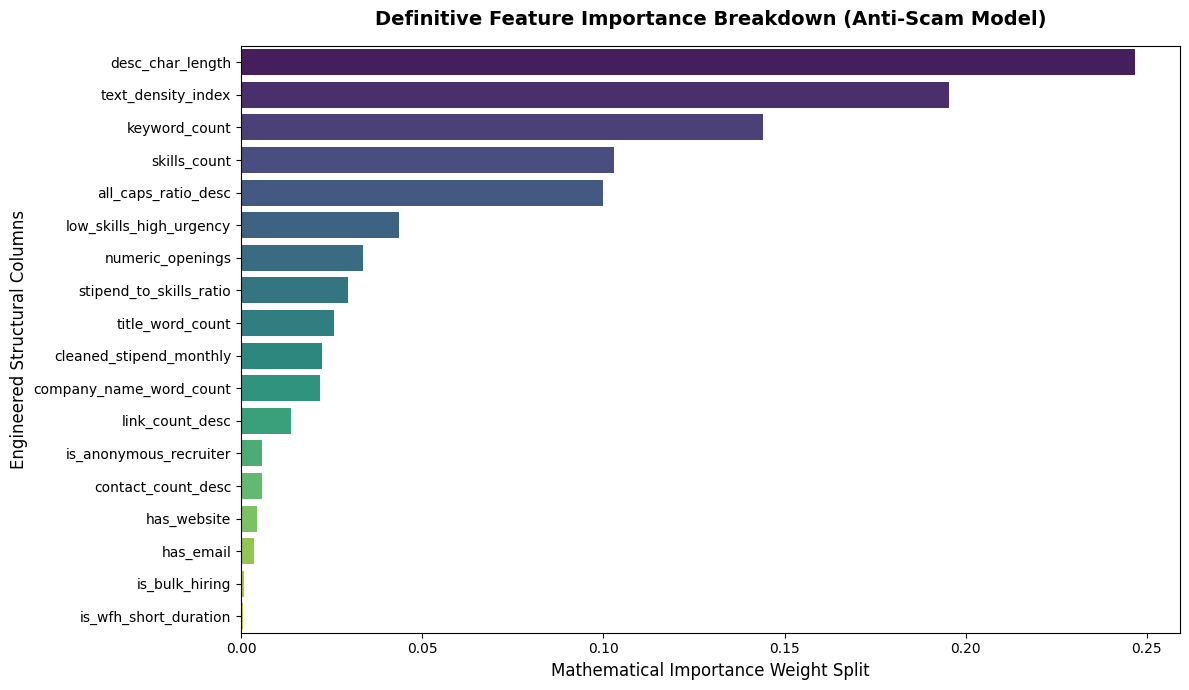

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Weight': importances
}).sort_values(by='Importance Weight', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Importance Weight', 
    y='Feature', 
    data=feature_importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('Definitive Feature Importance Breakdown (Anti-Scam Model)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mathematical Importance Weight Split', fontsize=12)
plt.ylabel('Engineered Structural Columns', fontsize=12)
plt.tight_layout()

# Save the visualization directly to disk for your presentation report
plt.savefig('model_feature_importances.png', dpi=300)
print("High-resolution feature importance visualization exported as 'model_feature_importances.png'!")

ROC Comparison Curve exported as 'model_roc_curve.png'!


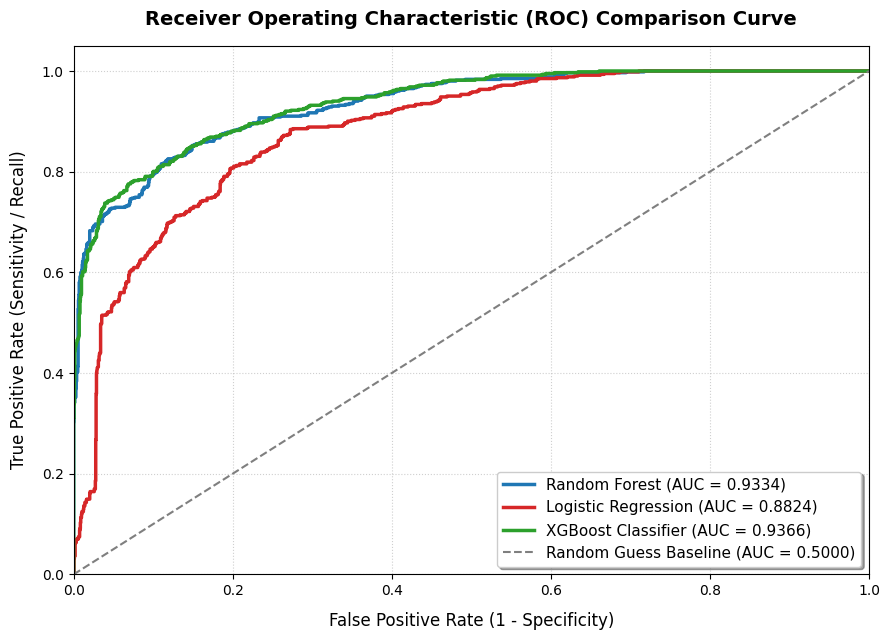

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

rf_proba = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)

lr_proba = lr_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fig, ax = plt.subplots(figsize=(9, 6.5))

ax.plot(fpr_rf, tpr_rf, color='#1f77b4', lw=2.5, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
ax.plot(fpr_lr, tpr_lr, color='#d62728', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')

try:
    xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
    roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
    ax.plot(fpr_xgb, tpr_xgb, color='#2ca02c', lw=2.5, label=f'XGBoost Classifier (AUC = {roc_auc_xgb:.4f})')
except NameError:
    print("⚠️ Note: xgb_model wasn't found in memory, skipping its curve line.")

ax.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.5, linestyle='--', label='Random Guess Baseline (AUC = 0.5000)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, labelpad=10)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12, labelpad=10)
ax.set_title('Receiver Operating Characteristic (ROC) Comparison Curve', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

plt.savefig('model_roc_curve.png', dpi=300)
print("ROC Comparison Curve exported as 'model_roc_curve.png'!")

In [14]:
from sklearn.model_selection import RandomizedSearchCV
param_distributions = {
    'n_estimators': [100, 150, 200],         
    'max_depth': [10, 15, 20, None],         
    'min_samples_split': [2, 5, 10],          
    'min_samples_leaf': [1, 2, 4],          
    'max_features': ['sqrt', 'log2', None]    
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_tuned_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=10,              
    cv=3,                    
    scoring='roc_auc',      
    random_state=42,
    n_jobs=-1               
)

print("Running Hyperparameter Tuning across folds...")
rf_tuned_search.fit(X_train, y_train)

print("\nOPTIMIZATION COMPLETE!")
print(f"Best Parameters Found: {rf_tuned_search.best_params_}")
print(f"Best Training Cross-Validation ROC-AUC: {rf_tuned_search.best_score_:.4f}")

best_rf_model = rf_tuned_search.best_estimator_
tuned_preds = best_rf_model.predict(X_test)
tuned_proba = best_rf_model.predict_proba(X_test)[:, 1]

print("\n ================= TUNED RANDOM FOREST PERFORMANCE ================= ")
print(classification_report(y_test, tuned_preds))
print(f"Final Tuned Out-of-Sample ROC-AUC Score: {roc_auc_score(y_test, tuned_proba):.4f}")

Running Hyperparameter Tuning across folds...

OPTIMIZATION COMPLETE!
Best Parameters Found: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}
Best Training Cross-Validation ROC-AUC: 0.9532

 ================= TUNED RANDOM FOREST PERFORMANCE ================= 
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      2122
           1       0.85      0.81      0.83       602

    accuracy                           0.93      2724
   macro avg       0.90      0.88      0.89      2724
weighted avg       0.93      0.93      0.93      2724

Final Tuned Out-of-Sample ROC-AUC Score: 0.9597
